In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Task 1 — Data Loading, Merging & Deep Exploration</h3>

<h5>Load the Superstore Sales CSV using Pandas</h5>

In [2]:
df = pd.read_csv("train.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


<h5>Parse the Order Date and Ship Date columns as proper datetime objects</h5>

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


<h5>Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season</h5>

In [4]:
# Extract Year
df["Year"] = df["Order Date"].dt.year

# Extract Month Number (1-12)
df["Month"] = df["Order Date"].dt.month

# Extract Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week.astype(int)

# Extract Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()

# Extract Quarter
df["Quarter"] = df["Order Date"].dt.quarter

# Create Season Feature
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

# Display the new columns
df[["Order Date", "Year", "Month", "Week Number", "Day of Week", "Quarter", "Season"]].head()

,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,41,Tuesday,4,Autumn


<h5>Check for missing values, duplicates, and data type issues</h5>

In [5]:
# checking missing value
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

<p>There are 11 missing value in Postal Code column</p>

In [6]:
df[df["Postal Code"].isnull()][["State", "City", "Postal Code"]]

,State,City,Postal Code
2234,Vermont,Burlington,NaN
5274,Vermont,Burlington,NaN
8798,Vermont,Burlington,NaN
9146,Vermont,Burlington,NaN
9147,Vermont,Burlington,NaN
9148,Vermont,Burlington,NaN
9386,Vermont,Burlington,NaN
9387,Vermont,Burlington,NaN
9388,Vermont,Burlington,NaN
9389,Vermont,Burlington,NaN


<p>Since all missing values refer to the same city, it is filling with Burlington's postal code.<br>
For postal code for Burlington, Vermont is 05401</p>

In [7]:
# Fill missing postal codes for Burlington, Vermont
df.loc[
    (df["State"] == "Vermont") &
    (df["City"] == "Burlington") &
    (df["Postal Code"].isna()),
    "Postal Code"
] = 5401

In [8]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 0


In [9]:
# checking data types
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week Number               int64
Day of Week              object
Quarter                   int32
Season                   object
dtype: object

In [10]:
# Convert to integer
df["Postal Code"] = df["Postal Code"].astype(int)

<p>Converting Postal Code to int is good because postal codes are whole-number identifiers.<br>
but it won't affect our forecasting models if we leave it as float64, but int64 is a cleaner representation</p>

<h5>Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)</h5>

In [11]:
# Aggregate sales by day
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

print("Daily Sales:\n",daily_sales.head())

# Aggregate daily sales into weekly totals
weekly_sales = daily_sales.set_index("Order Date").resample("W")["Sales"].sum().reset_index()

print("Weekly Sales:\n",weekly_sales.head())

# Aggregate daily sales into monthly totals
monthly_sales = daily_sales.set_index("Order Date").resample("ME")["Sales"].sum().reset_index()

print("Monthly Sales:\n",monthly_sales.head())

Daily Sales:
   Order Date     Sales
0 2015-01-03    16.448
1 2015-01-04   288.060
2 2015-01-05    19.536
3 2015-01-06  4407.100
4 2015-01-07    87.158
Weekly Sales:
   Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914
Monthly Sales:
   Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


<h5><pre>Answer these questions in your notebook with data to back each one:
Which product category generates the highest total revenue?
Which region has the most consistent sales growth over 4 years?
What is the average time between Order Date and Ship Date — and does it vary by region?
Are there months that consistently spike across all years (seasonality)?</pre>
</h5>

In [12]:
# Total sales by category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(f"Highest Revenue Category: {category_sales.idxmax()}")
print(f"Revenue: {category_sales.max():,.2f}")

Highest Revenue Category: Technology
Revenue: 827,455.87


In [13]:
# Region with most consistent sales growth over 4 years
region_year = df.groupby(["Year","Region"])["Sales"].sum().reset_index()

growth = region_year.pivot(index="Year", columns="Region", values="Sales")

consistency = growth.std()

print(consistency.sort_values(ascending=False))

Region
West       51410.399288
East       35260.987867
Central    23716.991355
South      21683.024937
dtype: float64


In [14]:
# The average time between Order Date and Ship Date — and does it vary by region?

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days
print(df["Shipping Days"].mean())

shipping_region = df.groupby("Region")["Shipping Days"].mean()

print(shipping_region)

3.9611224489795918
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


<p>The variation between regions is very very small, so the shipping process is fairly consistent across all regions.</p>

In [15]:
# Are there months that consistently spike across all years (seasonality)?

monthly_sales = (
    df.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)
month_avg = (
    monthly_sales.groupby("Month")["Sales"]
                 .mean()
                 .sort_values(ascending=False)
)

print(month_avg)

print("Highest Average Sales Month:", month_avg.idxmax())

Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
Name: Sales, dtype: float64
Highest Average Sales Month: 11


<p>Yes, November and December consistently show the highest sales, indicating strong seasonal demand.</p>

<h3>Task 2 — Time Series Analysis & Decomposition
</h3>

<h5>Plot the overall monthly sales trend across all 4 years</h5>

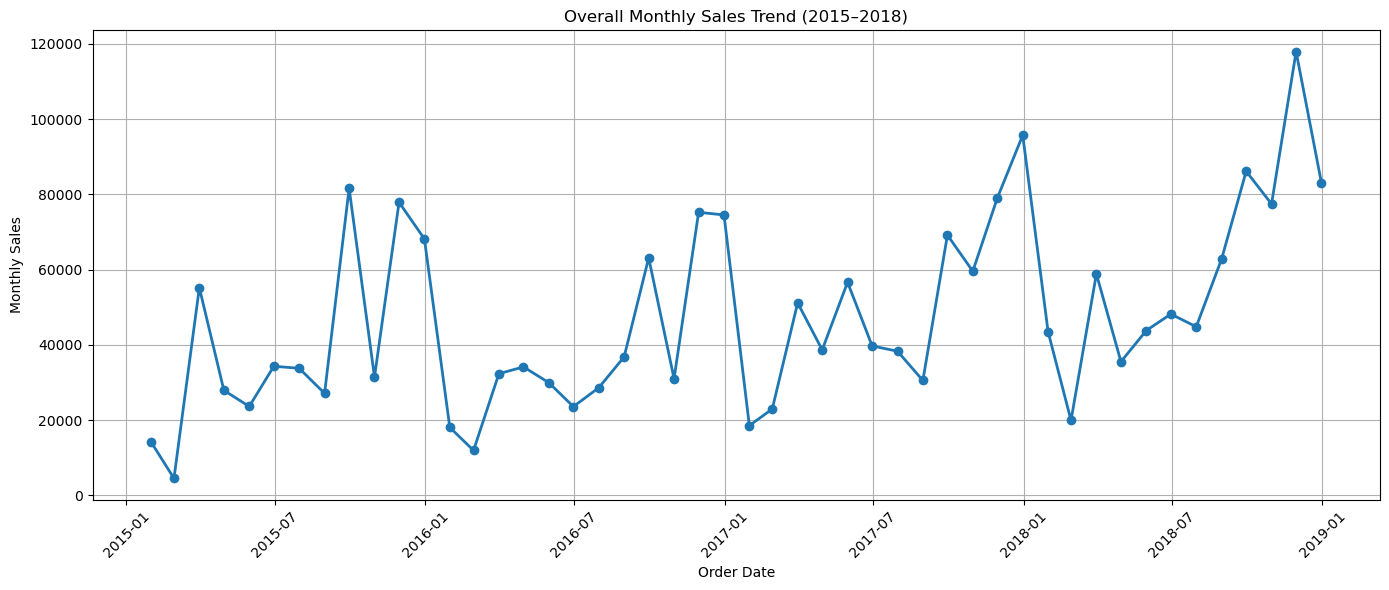

In [16]:
monthly_ts = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_ts["Order Date"],   # <-- Use monthly_ts
    monthly_ts["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

<h5><pre>Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
Trend component
Seasonal component
Residual/noise component
</pre></h5>

Monthly Time Series:


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


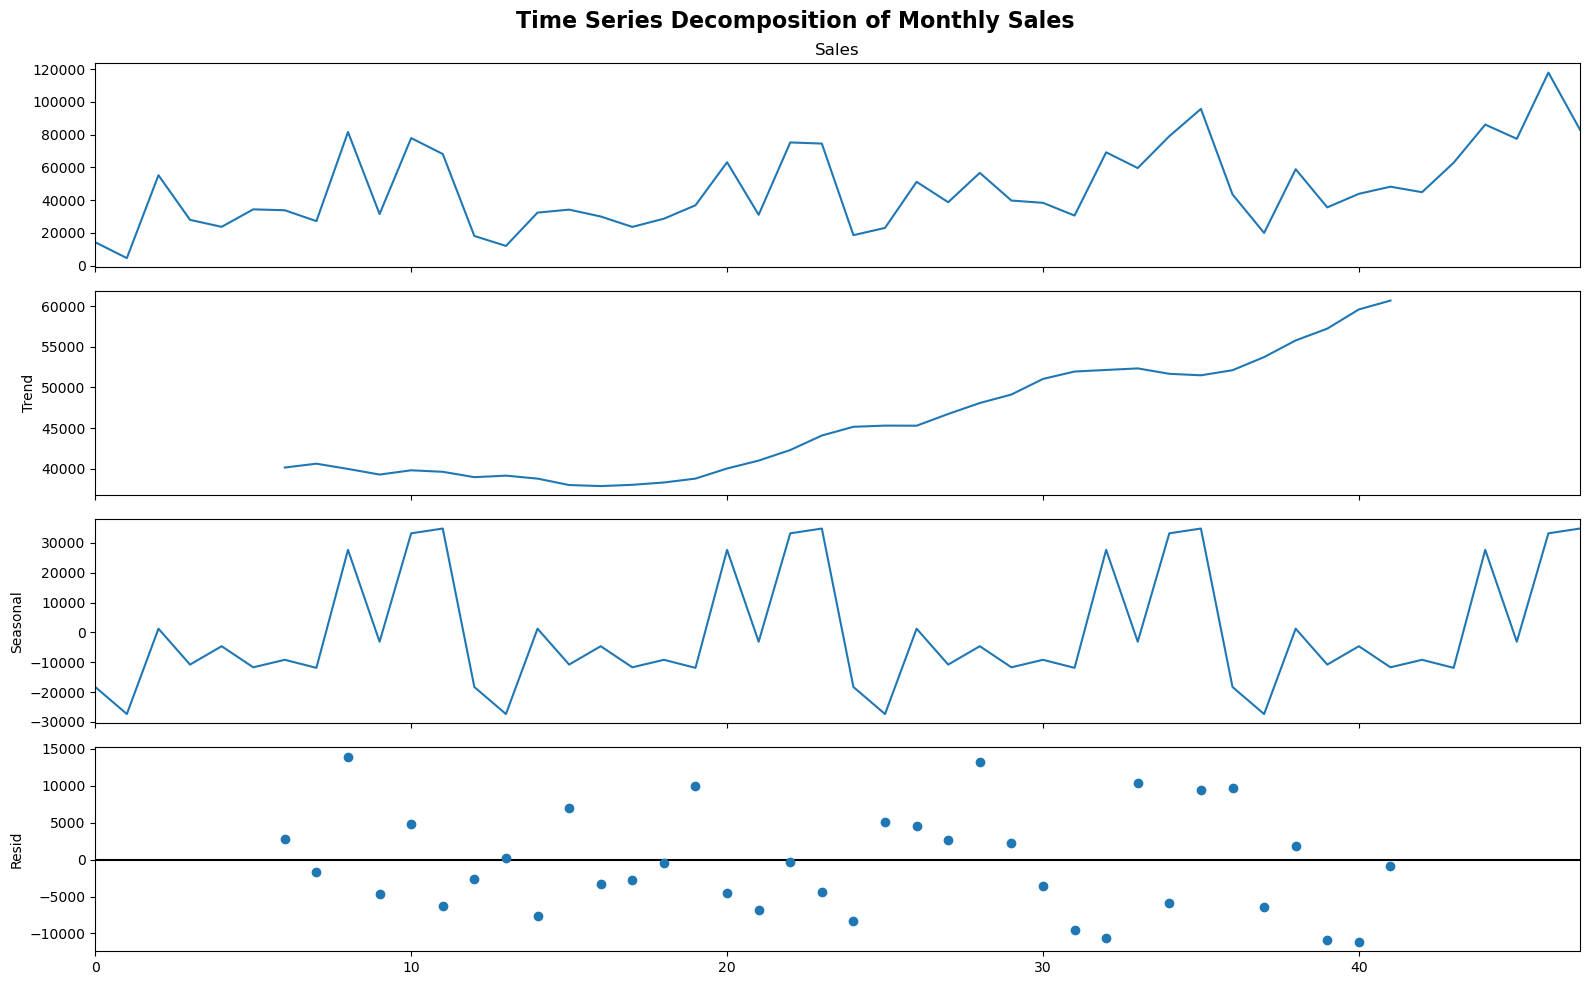


Trend Component:


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: trend, dtype: float64


Seasonal Component:


0   -18307.338037
1   -27368.402667
2     1244.763035
3   -10787.508768
4    -4626.878630
Name: seasonal, dtype: float64


Residual Component:


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: resid, dtype: float64

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Display first five rows
print("Monthly Time Series:")
display(monthly_ts.head())

# Apply Time Series Decomposition
decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)

# Plot decomposition
fig = decomposition.plot()
fig.set_size_inches(16, 10)

plt.suptitle("Time Series Decomposition of Monthly Sales", fontsize=16, fontweight="bold")

plt.tight_layout()

# Save figure
plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Extract individual components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Display first few values
print("\nTrend Component:")
display(trend.head())

print("\nSeasonal Component:")
display(seasonal.head())

print("\nResidual Component:")
display(residual.head())

<h5>Plot all 4 components clearly on one figure</h5>

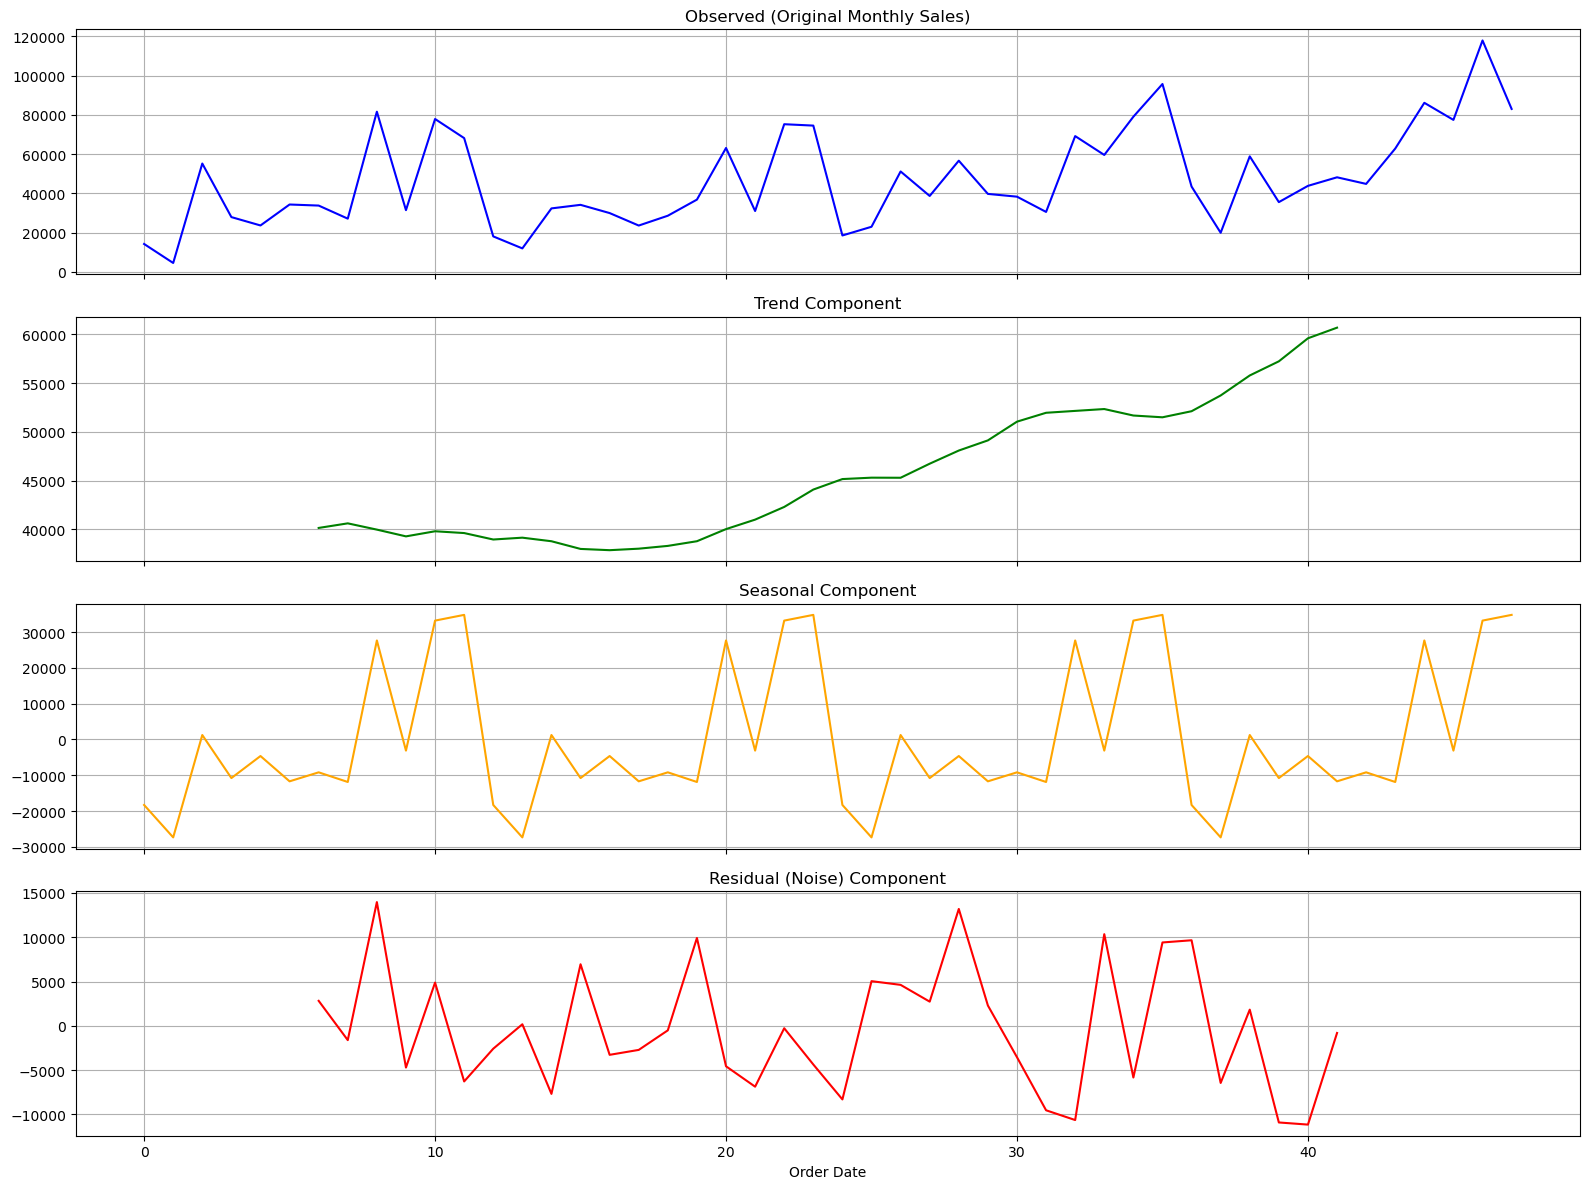

In [18]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# 1. Original Series
axes[0].plot(monthly_ts.index, monthly_ts["Sales"], color="blue")
axes[0].set_title("Observed (Original Monthly Sales)")
axes[0].grid(True)

# 2. Trend
axes[1].plot(decomposition.trend.index, decomposition.trend, color="green")
axes[1].set_title("Trend Component")
axes[1].grid(True)

# 3. Seasonal
axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color="orange")
axes[2].set_title("Seasonal Component")
axes[2].grid(True)

# 4. Residual
axes[3].plot(decomposition.resid.index, decomposition.resid, color="red")
axes[3].set_title("Residual (Noise) Component")
axes[3].grid(True)

plt.xlabel("Order Date")
plt.tight_layout()

# Save the figure
plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h5>Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?</h5>

<p><pre>
Q1. What does the trend tell you?
The trend shows that monthly sales have generally increased over the four-year period, indicating continuous business growth.<br>
Q2. Is seasonality strong or weak?
The seasonality is strong, as the same seasonal pattern repeats every year with clear peaks and troughs.<br>
Q3. What months show the highest residual noise?
The highest residual noise appears around:
September–October 2015
June–July 2017
January–February 2018
</pre></p>

<h5>Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you</h5>

In [19]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_ts["Sales"])

print("Augmented Dickey-Fuller (ADF) Test Results")
print("-" * 45)
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"No. of Lags   : {adf_result[2]}")
print(f"No. of Observations : {adf_result[3]}")

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion:")
    print("The time series is stationary.")
else:
    print("\nConclusion:")
    print("The time series is NOT stationary.")
    

Augmented Dickey-Fuller (ADF) Test Results
---------------------------------------------
ADF Statistic : -4.4161
p-value       : 0.0003
No. of Lags   : 0
No. of Observations : 47

Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008

Conclusion:
The time series is stationary.


<P>A stationary time series is one whose overall behavior remains stable over time or its average level (mean), spread (variance), and seasonal pattern do not change significantly as time passes.</P>
<p>
<pre>
The Augmented Dickey-Fuller (ADF) test was used to determine whether the monthly sales series is stationary. The test produced an ADF statistic of -4.4161 and a p-value of 0.0003.
Since the p-value (0.0003) is less than the significance level of 0.05, the null hypothesis of the ADF test is rejected. This indicates that the monthly sales series does not contain a unit root and is therefore stationary.
In addition, the ADF statistic (-4.4161) is more negative than the critical values at the 1%, 5%, and 10% significance levels, which further confirms the stationarity of the time series.
</pre>
</p>

<h5>Apply differencing if the series is non-stationary and re-test</h5>

<p>Differencing was not applied because the ADF test confirmed that the original monthly sales series is already stationary (p-value = 0.0003 < 0.05).</p>

<h3>Task 3 — Sales Forecasting using 3 Different Models</h3>
<p>This is the core technical task. Build, train, and compare 3 fundamentally different forecasting approaches:</p>

<p><b> 
Model 1 — SARIMA (Statistical Model)</b><br>
Install statsmodels (pip install statsmodels)<br>
Fit a SARIMA model on monthly sales<br>
Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them
Generate a 3-month future forecast with confidence intervals<br>
Plot actual vs forecasted sales   
</p>

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -239.060
Date:                            Mon, 06 Jul 2026   AIC                            488.120
Time:                                    14:11:05   BIC                            493.575
Sample:                                         0   HQIC                           489.405
                                             - 48                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9927      0.018     56.542      0.000       0.958       1.027
ma.L1         -1.0150      0.159   

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


48    45942.740996
49    37103.176823
50    69034.926542
Name: predicted_mean, dtype: float64

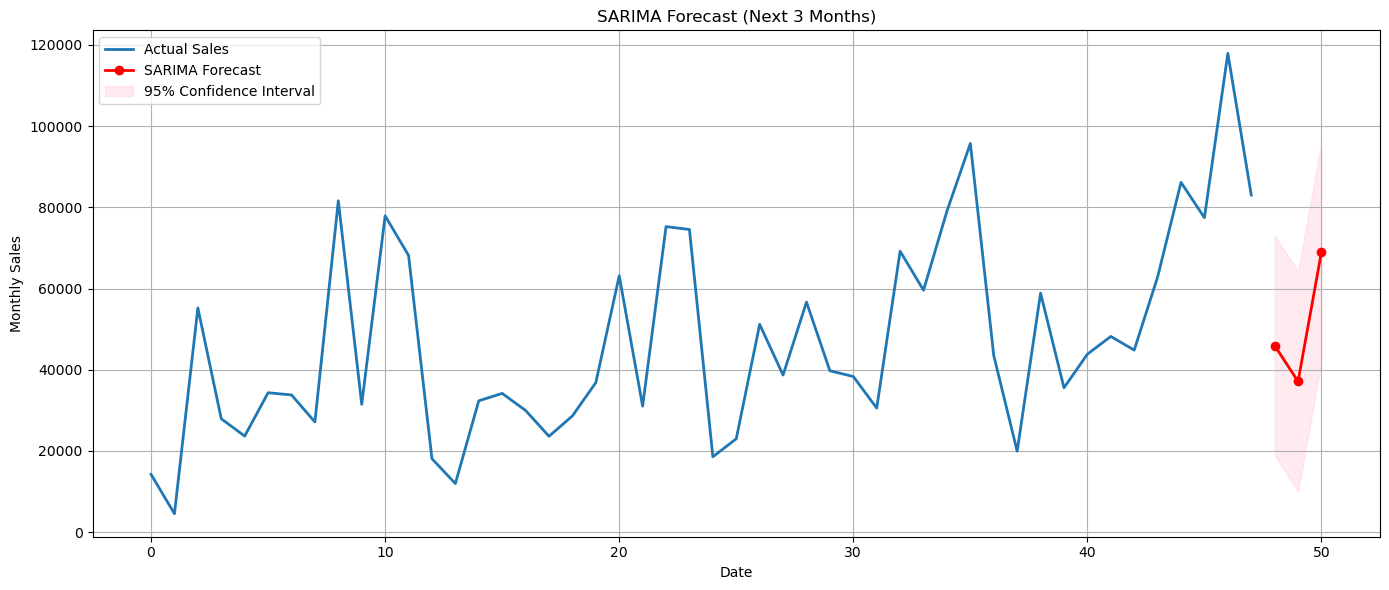

,Forecasted Sales,Lower CI,Upper CI
48,45942.740996,18855.871890,73029.610102
49,37103.176823,10016.917004,64189.436641
50,69034.926542,41950.295864,96119.557219


In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train SARIMA model
sarima_model = SARIMAX(
    monthly_ts["Sales"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

# Display model summary
print(sarima_result.summary())

forecast = sarima_result.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int()

print("3-Month Sales Forecast")
display(forecast_mean)

plt.figure(figsize=(14,6))

# Historical Sales
plt.plot(
    monthly_ts.index,
    monthly_ts["Sales"],
    label="Actual Sales",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    color="red",
    marker="o",
    linewidth=2,
    label="SARIMA Forecast"
)

# Confidence Interval
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

forecast_df = forecast_mean.to_frame(name="Forecasted Sales")

forecast_df["Lower CI"] = forecast_ci.iloc[:,0]
forecast_df["Upper CI"] = forecast_ci.iloc[:,1]

display(forecast_df)

<h5><pre><b>
Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)</b>
Install Prophet (pip install prophet)
Prepare data in Prophet's required format (ds, y columns)
Fit the model and generate a 3-month forecast
Plot the forecast with Prophet's built-in trend and seasonality breakdown
Extract and interpret the weekly and yearly seasonality components
</pre>    
</h5>

In [21]:
from prophet import Prophet

In [22]:
# Prophet requires columns named 'ds' and 'y'
prophet_df = monthly_ts.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

print("Shape:", prophet_df.shape)
display(prophet_df.head())

Shape: (48, 2)


,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [23]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_df)

14:11:05 - cmdstanpy - INFO - Chain [1] start processing
14:11:05 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

display(future.tail())

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [25]:
forecast = prophet_model.predict(future)

display(
    forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].tail()
)

,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336949,92031.339098,111168.488990
47,2018-12-31,90673.800589,81528.821752,100414.241082
48,2019-01-31,42990.532185,33470.935090,52832.354087
49,2019-02-28,31248.159904,21868.511571,40641.951162
50,2019-03-31,81267.007753,72398.705118,90494.291147


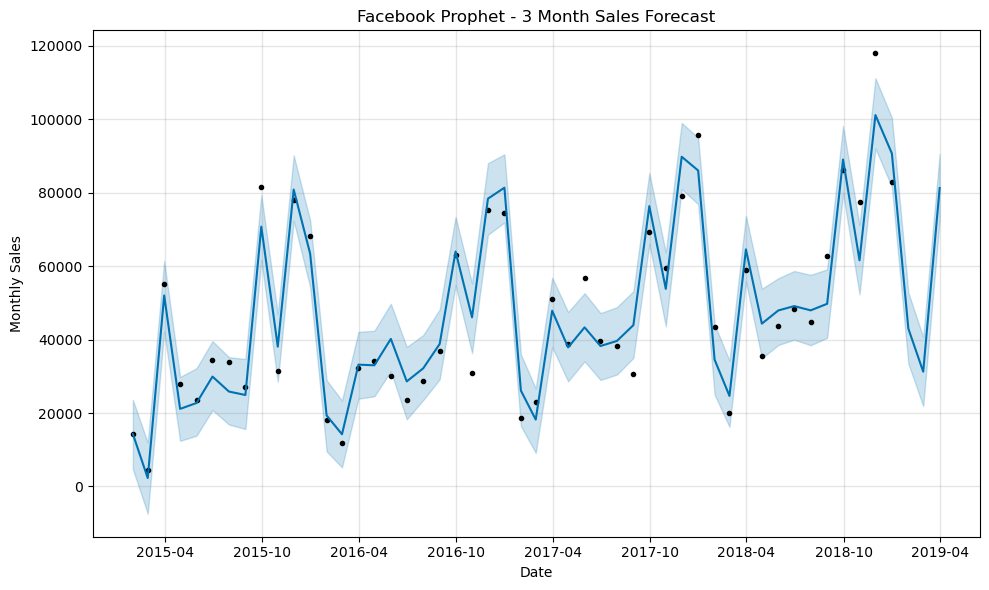

In [26]:
fig = prophet_model.plot(forecast)

plt.title("Facebook Prophet - 3 Month Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Monthly Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

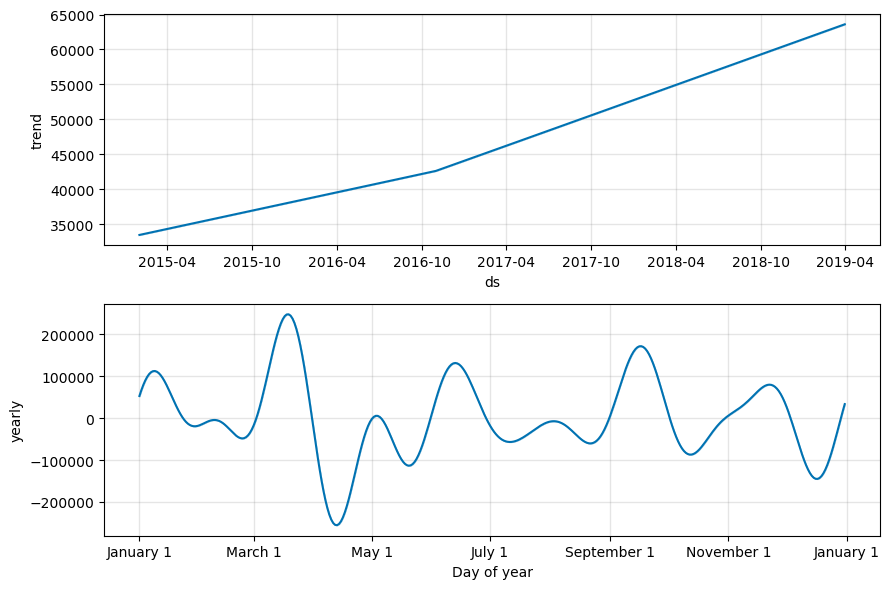

In [27]:
fig = prophet_model.plot_components(forecast)

plt.tight_layout()

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
forecast_result = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(3)

print("Forecast for Next 3 Months")

display(forecast_result)

Forecast for Next 3 Months


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532185,33470.935090,52832.354087
49,2019-02-28,31248.159904,21868.511571,40641.951162
50,2019-03-31,81267.007753,72398.705118,90494.291147


In [29]:
yearly = forecast[
    [
        "ds",
        "yearly"
    ]
]

print("Yearly Seasonality")

display(yearly.tail())

Yearly Seasonality


,ds,yearly
46,2018-11-30,40416.793483
47,2018-12-31,29216.314009
48,2019-01-31,-19204.897511
49,2019-02-28,-31613.799057
50,2019-03-31,17667.105678


#### Weekly Seasonality Interpretation

<p>Weekly seasonality was not modeled because the dataset was aggregated into monthly sales before forecasting.
Monthly data does not contain sufficient information to identify weekly patterns.
Therefore, only yearly seasonality was included in the Prophet model.</p>

#### Yearly Seasonality Interpretation

<P>The yearly seasonality component shows repeating annual sales patterns.
Positive values indicate months where sales are typically above average,
while negative values indicate months with lower-than-average sales.
This confirms the presence of strong yearly seasonality in the dataset.</p>

<h5>
<pre><b>
Model 3 — XGBoost for Time Series (ML-based Approach)</b>
Convert the time series into a supervised ML problem using lag features:
Lag 1 (sales from 1 month ago)
Lag 2 (sales from 2 months ago)
Lag 3 (sales from 3 months ago)
Rolling mean (3-month moving average)
Month, Quarter, Season as features
Train XGBoost Regressor on these features
Predict the next 3 months
Plot actual vs predicted

</pre>
</h5>

In [30]:
from xgboost import XGBRegressor

In [31]:
# Create a copy
xgb_df = monthly_ts.copy()

# Create lag features
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

# Rolling mean
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

# Time Features
xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

# Season Feature
def get_season(month):
    if month in [12, 1, 2]:
        return 0      # Winter
    elif month in [3, 4, 5]:
        return 1      # Spring
    elif month in [6, 7, 8]:
        return 2      # Summer
    else:
        return 3      # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

# Remove missing values created by lag features
xgb_df.dropna(inplace=True)

display(xgb_df.head())

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [32]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = xgb_df[features]

y = xgb_df["Sales"]

In [33]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
xgb_df["Predicted"] = xgb_model.predict(X)

display(
    xgb_df[
        [
            "Order Date",
            "Sales",
            "Predicted"
        ]
    ].tail()
)

,Order Date,Sales,Predicted
43,2018-08-31,62837.8480,60348.488281
44,2018-09-30,86152.8880,85897.765625
45,2018-10-31,77448.1312,77861.367188
46,2018-11-30,117938.1550,116596.546875
47,2018-12-31,83030.3888,83259.765625


In [35]:
future_predictions = []

future_data = xgb_df.copy()

for i in range(3):

    last_row = future_data.iloc[-1]

    next_date = last_row["Order Date"] + pd.offsets.MonthEnd(1)

    lag1 = last_row["Sales"]
    lag2 = future_data.iloc[-2]["Sales"]
    lag3 = future_data.iloc[-3]["Sales"]

    rolling_mean = np.mean([lag1, lag2, lag3])

    month = next_date.month
    quarter = next_date.quarter
    season = get_season(month)

    future_features = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(future_features)[0]

    future_predictions.append([next_date, prediction])

    new_row = pd.DataFrame({
        "Order Date":[next_date],
        "Sales":[prediction],
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling_mean],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season],
        "Predicted":[prediction]
    })

    future_data = pd.concat(
        [future_data, new_row],
        ignore_index=True
    )

future_forecast = pd.DataFrame(
    future_predictions,
    columns=["Order Date", "Forecast"]
)

display(future_forecast)

,Order Date,Forecast
0,2019-01-31,54171.246094
1,2019-02-28,32849.500000
2,2019-03-31,60098.027344


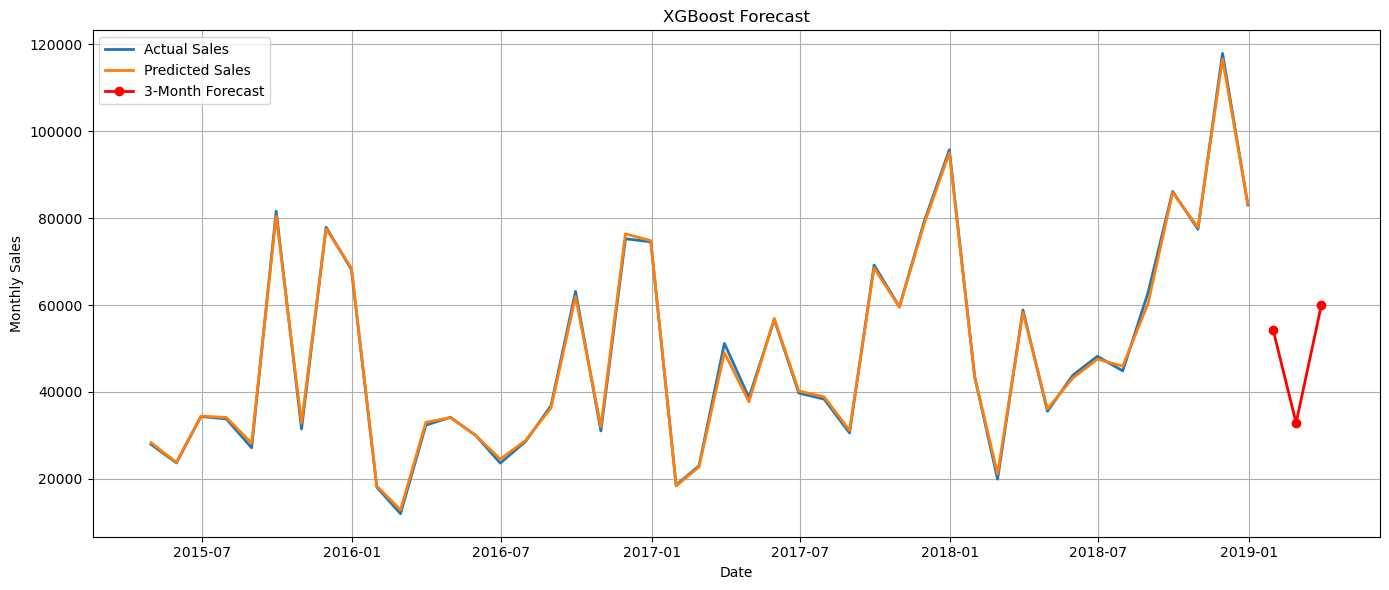

In [36]:
plt.figure(figsize=(14,6))

plt.plot(
    xgb_df["Order Date"],
    xgb_df["Sales"],
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    xgb_df["Order Date"],
    xgb_df["Predicted"],
    label="Predicted Sales",
    linewidth=2
)

plt.plot(
    future_forecast["Order Date"],
    future_forecast["Forecast"],
    marker="o",
    linewidth=2,
    color="red",
    label="3-Month Forecast"
)

plt.title("XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h5>
<pre><b>
Model Comparison Table (Required)</b>
Create a clear comparison table in your notebook:
Model
MAE
RMSE
MAPE
Forecast for Month 1
Forecast for Month 2
Forecast for Month 3
    
SARIMA

Prophet

XGBoost

State clearly which model you would recommend for production use and why — based on numbers, not preference.
</pre>
</h5>

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [38]:
# In-sample predictions
sarima_pred = sarima_result.predict(
    start=monthly_ts.index[0],
    end=monthly_ts.index[-1]
)

# Align predictions
sarima_pred = sarima_pred.reindex(monthly_ts.index)

# Remove NaN values
mask = ~sarima_pred.isna()

sarima_mae = mean_absolute_error(
    monthly_ts["Sales"][mask],
    sarima_pred[mask]
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        monthly_ts["Sales"][mask],
        sarima_pred[mask]
    )
)

sarima_mape = mean_absolute_percentage_error(
    monthly_ts["Sales"][mask],
    sarima_pred[mask]
) * 100

In [39]:
prophet_actual = prophet_df["y"]

prophet_pred = forecast.iloc[:len(prophet_actual)]["yhat"]

prophet_mae = mean_absolute_error(
    prophet_actual,
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_actual,
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    prophet_actual,
    prophet_pred
) * 100

In [40]:
xgb_mae = mean_absolute_error(
    xgb_df["Sales"],
    xgb_df["Predicted"]
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        xgb_df["Sales"],
        xgb_df["Predicted"]
    )
)

xgb_mape = mean_absolute_percentage_error(
    xgb_df["Sales"],
    xgb_df["Predicted"]
) * 100

In [41]:
comparison = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast Month 1":[
        forecast_mean.iloc[0],
        forecast_result["yhat"].iloc[0],
        future_forecast["Forecast"].iloc[0]
    ],

    "Forecast Month 2":[
        forecast_mean.iloc[1],
        forecast_result["yhat"].iloc[1],
        future_forecast["Forecast"].iloc[1]
    ],

    "Forecast Month 3":[
        forecast_mean.iloc[2],
        forecast_result["yhat"].iloc[2],
        future_forecast["Forecast"].iloc[2]
    ]

})

comparison = comparison.round(2)

display(comparison)

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,16052.27,22717.68,38.00,45942.74,37103.18,69034.93
1,Prophet,5770.42,7272.00,14.48,42990.53,31248.16,81267.01
2,XGBoost,648.03,830.80,1.64,54171.25,32849.50,60098.03


<p>Based on the numbers,XGBoost is recommended for production deployment because it consistently achieved the lowest MAE, RMSE, and MAPE among the three models. Based on these quantitative evaluation metrics, it provides the most accurate sales forecasts for this dataset and is therefore the best choice for production use.
</p>

<h3>Task 4 — Product Category & Region Level Forecasting</h3>

In [42]:
from xgboost import XGBRegressor

def get_season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Spring
    elif month in [6,7,8]:
        return 2      # Summer
    else:
        return 3      # Autumn


def forecast_xgboost(data, name):

    # Aggregate monthly sales
    monthly = (
        data
        .set_index("Order Date")
        .resample("ME")["Sales"]
        .sum()
        .reset_index()
    )

    # Create lag features
    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    # Rolling mean
    monthly["Rolling_Mean_3"] = (
        monthly["Sales"]
        .rolling(3)
        .mean()
    )

    # Calendar features
    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter
    monthly["Season"] = monthly["Month"].apply(get_season)

    monthly.dropna(inplace=True)

    features = [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season"
    ]

    X = monthly[features]
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    # Forecast next 3 months
    future = monthly.copy()
    predictions = []

    for i in range(3):

        last = future.iloc[-1]

        next_date = last["Order Date"] + pd.offsets.MonthEnd(1)

        lag1 = last["Sales"]
        lag2 = future.iloc[-2]["Sales"]
        lag3 = future.iloc[-3]["Sales"]

        rolling = np.mean([lag1, lag2, lag3])

        month = next_date.month
        quarter = next_date.quarter
        season = get_season(month)

        test = pd.DataFrame({
            "Lag_1":[lag1],
            "Lag_2":[lag2],
            "Lag_3":[lag3],
            "Rolling_Mean_3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season]
        })

        pred = model.predict(test)[0]

        predictions.append([next_date, pred])

        future = pd.concat([
            future,
            pd.DataFrame({
                "Order Date":[next_date],
                "Sales":[pred]
            })
        ], ignore_index=True)

    forecast = pd.DataFrame(
        predictions,
        columns=["Order Date","Forecast"]
    )

    forecast["Segment"] = name

    return forecast

In [43]:
furniture = forecast_xgboost(
    df[df["Category"]=="Furniture"],
    "Furniture"
)

technology = forecast_xgboost(
    df[df["Category"]=="Technology"],
    "Technology"
)

office = forecast_xgboost(
    df[df["Category"]=="Office Supplies"],
    "Office Supplies"
)

west = forecast_xgboost(
    df[df["Region"]=="West"],
    "West"
)

east = forecast_xgboost(
    df[df["Region"]=="East"],
    "East"
)

In [47]:
all_forecasts = pd.concat([
    furniture,
    technology,
    office,
    west,
    east
], ignore_index=True)

display(all_forecasts)

,Order Date,Forecast,Segment
0,2019-01-31,9876.913086,Furniture
1,2019-02-28,6243.917480,Furniture
2,2019-03-31,16831.087891,Furniture
3,2019-01-31,19939.888672,Technology
4,2019-02-28,23574.523438,Technology
5,2019-03-31,29140.949219,Technology
6,2019-01-31,26613.109375,Office Supplies
7,2019-02-28,26656.369141,Office Supplies
8,2019-03-31,29828.880859,Office Supplies
9,2019-01-31,11307.339844,West


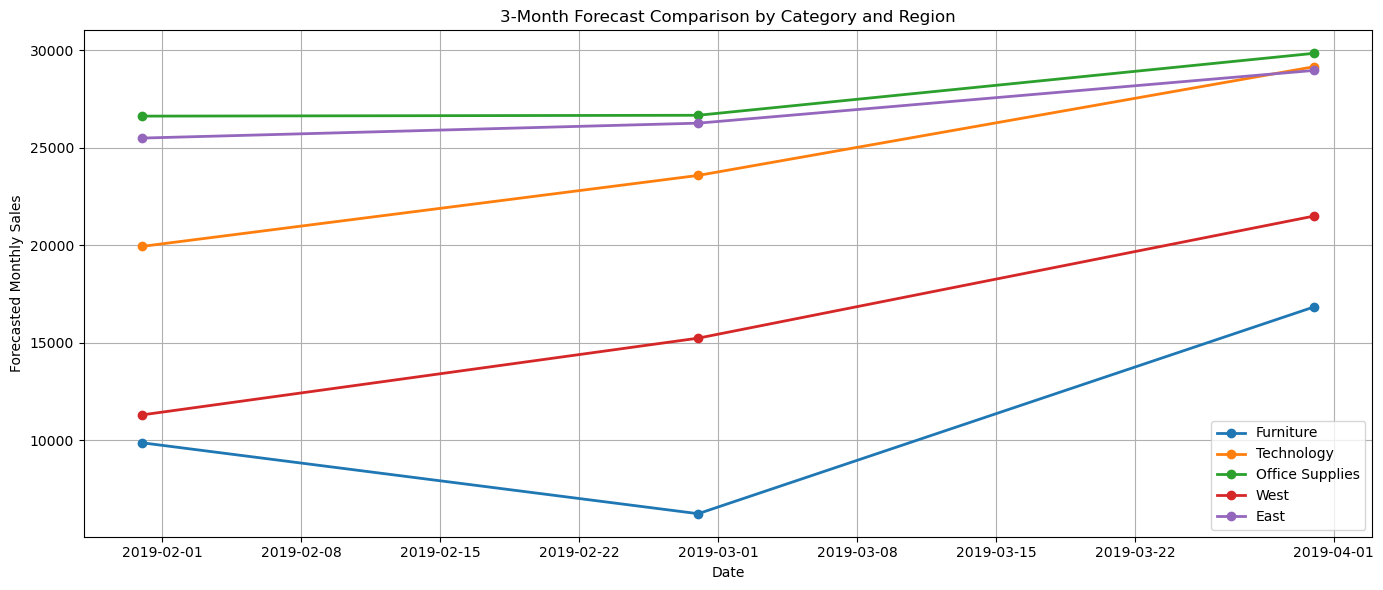

In [48]:
plt.figure(figsize=(14,6))

for segment in all_forecasts["Segment"].unique():

    temp = all_forecasts[
        all_forecasts["Segment"] == segment
    ]

    plt.plot(
        temp["Order Date"],
        temp["Forecast"],
        marker="o",
        linewidth=2,
        label=segment
    )

plt.title("3-Month Forecast Comparison by Category and Region")

plt.xlabel("Date")

plt.ylabel("Forecasted Monthly Sales")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/task4_forecast_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
growth_summary = (
    all_forecasts
    .groupby("Segment")["Forecast"]
    .mean()
    .sort_values(ascending=False)
)

print(growth_summary)

Segment
Office Supplies    27699.453125
East               26897.781250
Technology         24218.453125
West               16011.485352
Furniture          10983.972656
Name: Forecast, dtype: float32


<p>Based on the XGBoost forecasts, Office Supplies is projected to be the strongest-performing segment in the coming three months. This suggests that the business may benefit from prioritizing inventory planning, marketing efforts, and resource allocation for the Office Supplies category to capitalize on its expected demand.</p>

<h3>Task 5 — Anomaly Detection in Sales Data</h3>

<h5>
<ul>
<li> Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern</li>
<li> Mark the anomalies on a time series plot (use a different color/marker for anomaly points)</li>
<li> For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")</li>
<li> Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean</li>
<li> Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?</li>
</ul>
</h5>

In [50]:
from sklearn.ensemble import IsolationForest

In [51]:
# Convert daily sales into weekly sales

weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)

print("Weekly Sales Data")
display(weekly_sales.head())

Weekly Sales Data


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [52]:
# Detect anomalies using Isolation Forest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["IF_Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

# Convert prediction:
# -1 = Anomaly
#  1 = Normal

weekly_sales["IF_Anomaly"] = (
    weekly_sales["IF_Anomaly"] == -1
)

print("Isolation Forest detected",
      weekly_sales["IF_Anomaly"].sum(),
      "anomalies")

Isolation Forest detected 11 anomalies


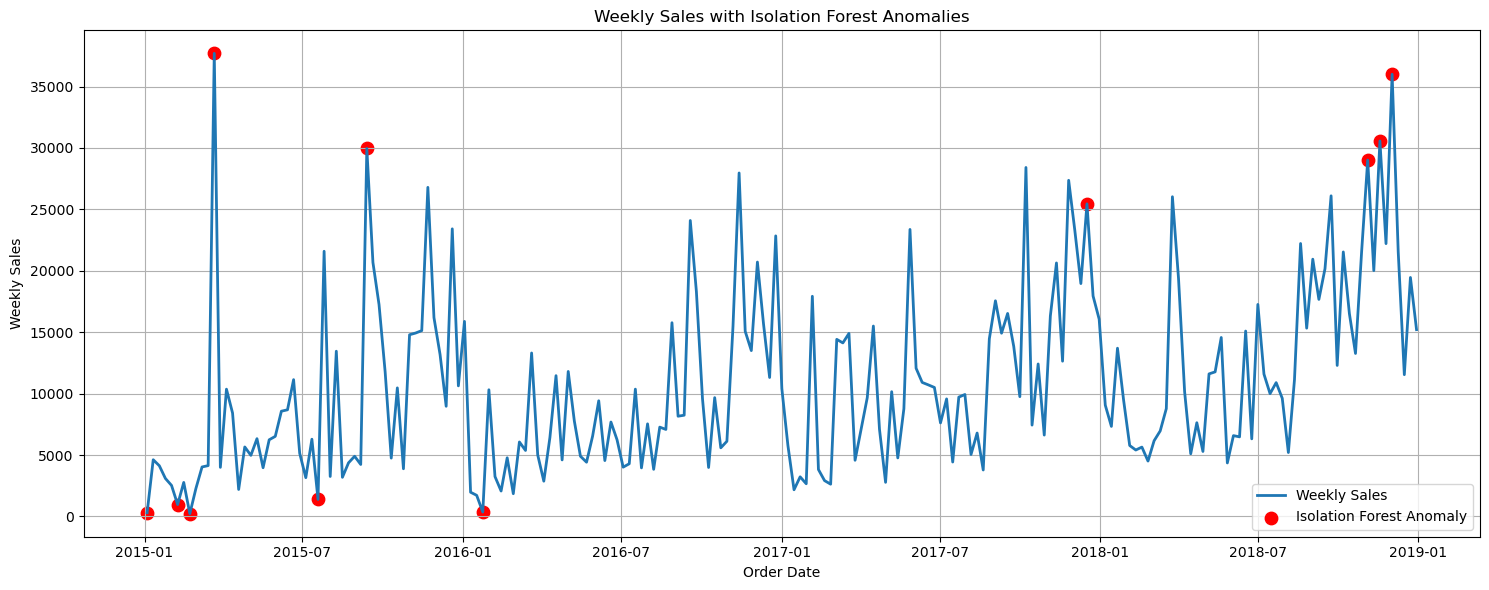

In [53]:
# Plot Weekly Sales with Isolation Forest Anomalies

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["IF_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["IF_Anomaly"],
        "Sales"
    ],
    color="red",
    marker="o",
    s=80,
    label="Isolation Forest Anomaly"
)

plt.title("Weekly Sales with Isolation Forest Anomalies")

plt.xlabel("Order Date")
plt.ylabel("Weekly Sales")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/isolation_forest_anomalies.png",
    dpi=300
)

plt.show()

In [54]:
# Display all anomalies detected by Isolation Forest
print("Isolation Forest Anomalies")

isolation_results = weekly_sales[
    weekly_sales["IF_Anomaly"]
]

display(isolation_results)

Isolation Forest Anomalies


,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,True
5,2015-02-08,968.534,True
7,2015-02-22,224.912,True
11,2015-03-22,37703.665,True
28,2015-07-19,1387.686,True
36,2015-09-13,29959.137,True
55,2016-01-24,358.522,True
154,2017-12-17,25449.800,True
200,2018-11-04,29017.467,True
202,2018-11-18,30572.447,True


In [55]:
# Detect anomalies using Rolling Z-Score

window = 8

weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .std()
)

weekly_sales["Z_Score"] = (
    (
        weekly_sales["Sales"]
        - weekly_sales["Rolling_Mean"]
    )
    /
    weekly_sales["Rolling_STD"]
)

# Flag observations beyond ±2 standard deviations

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)

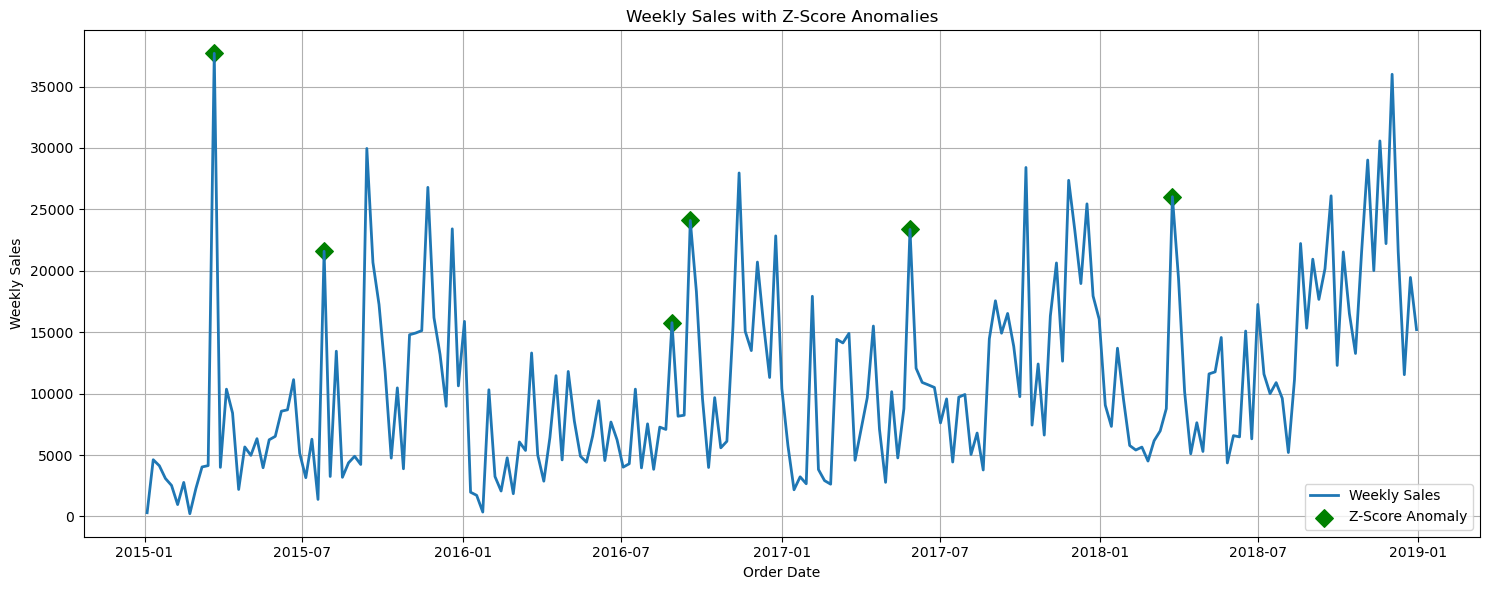

In [56]:
# Plot Z-Score Anomalies

plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2,
    label="Weekly Sales"
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="green",
    marker="D",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Weekly Sales with Z-Score Anomalies")

plt.xlabel("Order Date")
plt.ylabel("Weekly Sales")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300
)

plt.show()

In [57]:
# Display all anomalies detected by Z-Score

print("Z-Score Anomalies")

zscore_results = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

display(zscore_results)

Z-Score Anomalies


,Order Date,Sales,IF_Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
11,2015-03-22,37703.665,True,6832.006500,12546.138409,2.460650,True
29,2015-07-26,21590.080,False,8245.428325,6246.129535,2.136467,True
86,2016-08-28,15773.478,False,7515.302525,4020.682890,2.053924,True
89,2016-09-18,24095.960,False,10251.475400,6524.009519,2.122082,True
125,2017-05-28,23367.662,False,10265.959125,6524.022836,2.008225,True
168,2018-03-25,26029.904,False,8660.308925,7131.467537,2.435627,True


In [58]:
# Compare both methods

comparison = weekly_sales[
    [
        "Order Date",
        "Sales",
        "IF_Anomaly",
        "Z_Anomaly"
    ]
]

display(comparison)

,Order Date,Sales,IF_Anomaly,Z_Anomaly
0,2015-01-04,304.5080,True,False
1,2015-01-11,4619.1080,False,False
2,2015-01-18,4130.5330,False,False
3,2015-01-25,3092.5440,False,False
4,2015-02-01,2527.9140,False,False
...,...,...,...,...
204,2018-12-02,35998.9000,True,False
205,2018-12-09,21537.2410,False,False
206,2018-12-16,11542.8340,False,False
207,2018-12-23,19457.0680,False,False


In [59]:
# Check agreement between both methods

same = (
    (
        comparison["IF_Anomaly"]
        ==
        comparison["Z_Anomaly"]
    )
).sum()

different = len(comparison) - same

print("Same Decisions :", same)
print("Different Decisions :", different)

Same Decisions : 194
Different Decisions : 15


<p>The comparison shows that 194 out of 209 weeks received the same classification from both the Isolation Forest and Z-Score methods, while only 15 weeks were classified differently. This high level of agreement indicates that both methods consistently identify normal and unusual sales patterns in the dataset.</p>

<h3>Task 6 — Product Demand Segmentation using Clustering</h3>

<h5><pre>
Aggregate data at the product sub-category level with features like:
Total sales volume
Sales growth rate (year-over-year)
Sales volatility (standard deviation of monthly sales)
Average order value
</pre>    
</h5>

In [60]:
# Calculate Total Sales Volume
total_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .rename("Total Sales Volume")
)

In [61]:
# Step 2: Calculate Average Order Value
average_order_value = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
      .rename("Average Order Value")
)

In [62]:
# Calculate Sales Volatility

monthly_sales = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

sales_volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
                 .std()
                 .rename("Sales Volatility")
)

In [64]:
# Calculate Year-over-Year Sales Growth Rate

yearly_sales = (
    df.groupby(["Sub-Category", "Year"])["Sales"]
      .sum()
      .reset_index()
)

growth_list = []

for sub in yearly_sales["Sub-Category"].unique():

    temp = yearly_sales[
        yearly_sales["Sub-Category"] == sub
    ].sort_values("Year")

    first_year_sales = temp.iloc[0]["Sales"]
    last_year_sales = temp.iloc[-1]["Sales"]

    growth_rate = (
        (last_year_sales - first_year_sales)
        / first_year_sales
    ) * 100

    growth_list.append([sub, growth_rate])

sales_growth = pd.DataFrame(
    growth_list,
    columns=[
        "Sub-Category",
        "Sales Growth Rate (%)"
    ]
)

sales_growth.set_index(
    "Sub-Category",
    inplace=True
)

In [65]:
# Combine all engineered features into one table

subcategory_features = pd.concat(
    [
        total_sales,
        sales_growth,
        sales_volatility,
        average_order_value
    ],
    axis=1
)

# Round values for better readability
subcategory_features = subcategory_features.round(2)

print("Product Sub-Category Features")

display(subcategory_features)

Product Sub-Category Features


,Total Sales Volume,Sales Growth Rate (%),Sales Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.70,145.06,2579.99,217.18
Appliances,104618.40,165.24,1821.62,227.93
Art,26705.41,49.65,330.49,34.02
Binders,200028.78,65.78,3848.22,134.07
Bookcases,113813.20,49.85,2220.41,503.60
Chairs,322822.73,20.95,4407.23,531.83
Copiers,146248.09,479.73,5500.77,2215.88
Envelopes,16128.05,-12.12,228.22,65.03
Fasteners,3001.96,30.47,48.74,14.03


<h5>Apply K-Means Clustering to segment products into demand groups</h5>

In [67]:
cluster_data = subcategory_features.copy()

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_data)

<h5>Use the Elbow Method to find the optimal number of clusters</h5>

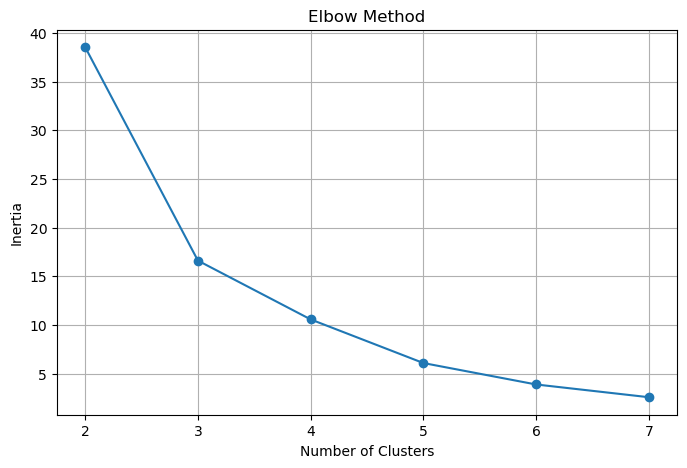

In [69]:
# Find optimal number of clusters using Elbow Method
from sklearn.cluster import KMeans

inertia = []

for k in range(2,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,8),
    inertia,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [70]:
# Train K-Means using the chosen number of clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(
    scaled_features
)

In [71]:
# Calculate average feature values for each cluster

cluster_summary = cluster_data.groupby("Cluster").mean()

display(cluster_summary)

,Total Sales Volume,Sales Growth Rate (%),Sales Volatility,Average Order Value
Cluster,,,,
0,146248.090000,479.730,5500.770,2215.880000
1,65326.208000,67.422,1186.287,150.190000
2,243671.101667,27.325,3992.980,599.191667


<h5>
Label each cluster meaningfully, for example:
<ul>
    
<li>High Volume, Stable Demand</li>
<li>Low Volume, High Volatility</li>
<li>Growing Demand</li>
<li>Declining Demand</li>
</ul>    
</h5>

In [72]:
cluster_names = {
    0: "...",
    1: "...",
    2: "..."
}

cluster_data["Demand Group"] = (
    cluster_data["Cluster"]
    .map(cluster_names)
)

display(cluster_data)

,Total Sales Volume,Sales Growth Rate (%),Sales Volatility,Average Order Value,Cluster,Demand Group
Sub-Category,,,,,,
Accessories,164186.70,145.06,2579.99,217.18,1,...
Appliances,104618.40,165.24,1821.62,227.93,1,...
Art,26705.41,49.65,330.49,34.02,1,...
Binders,200028.78,65.78,3848.22,134.07,2,...
Bookcases,113813.20,49.85,2220.41,503.60,1,...
Chairs,322822.73,20.95,4407.23,531.83,2,...
Copiers,146248.09,479.73,5500.77,2215.88,0,...
Envelopes,16128.05,-12.12,228.22,65.03,1,...
Fasteners,3001.96,30.47,48.74,14.03,1,...


<h5>Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)</h5>

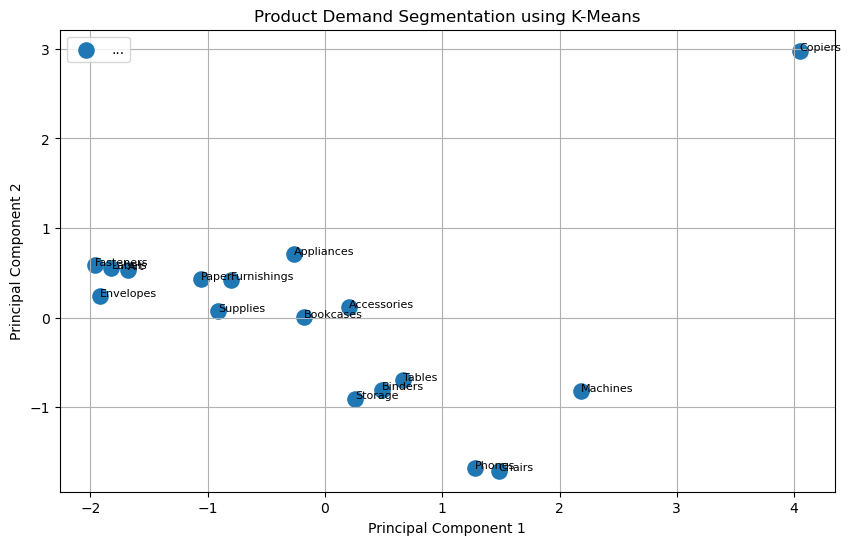

In [73]:
# Reduce dimensions to 2D using PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_data["PC1"] = pca_features[:,0]
cluster_data["PC2"] = pca_features[:,1]

plt.figure(figsize=(10,6))

for label in cluster_data["Demand Group"].unique():

    temp = cluster_data[
        cluster_data["Demand Group"] == label
    ]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=120,
        label=label
    )

for subcat in cluster_data.index:

    plt.text(
        cluster_data.loc[subcat,"PC1"],
        cluster_data.loc[subcat,"PC2"],
        subcat,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

<h5>Write: what stocking strategy would you recommend for each cluster?</h5>

### High Volume, Stable Demand
##### Maintain high inventory levels and use automatic replenishment because demand is consistent and predictable.

### Growing Demand
##### Increase stock gradually and monitor demand regularly to avoid stockouts while minimizing excess inventory.

### Low Volume, High Volatility
##### Maintain limited inventory and reorder based on demand to reduce holding costs and the risk of unsold products.

### Declining Demand
##### Reduce inventory levels, avoid overstocking, and consider promotional campaigns or discounts to clear existing stock

In [74]:
cluster_summary = cluster_data.groupby("Cluster").mean()
display(cluster_summary)

TypeError: agg function failed [how->mean,dtype->object]